In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")

from src.data_processing import download_data, calculate_returns, calculate_risk_metrics, run_adf_tests
from src.forecasting import train_arima_model, forecast_future_prices
from src.portfolio_optimization import (
    optimize_portfolio,
    minimum_volatility_portfolio,
    portfolio_performance,
    simulate_random_portfolios
)
from src.backtesting import backtest_strategy

os.makedirs("../figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

prices = download_data()
returns = calculate_returns(prices)

prices.to_csv("../data/processed/asset_prices.csv")
returns.to_csv("../data/processed/daily_returns.csv")

risk_metrics = calculate_risk_metrics(returns)
risk_metrics.to_csv("../data/processed/risk_metrics.csv")

adf_prices = run_adf_tests(prices)
adf_returns = run_adf_tests(returns)

adf_prices.to_csv("../data/processed/adf_prices.csv", index=False)
adf_returns.to_csv("../data/processed/adf_returns.csv", index=False)

print("Data ready")
display(prices.head())
display(risk_metrics)

ImportError: cannot import name 'run_adf_tests' from 'src.data_processing' (c:\Users\nfepo\Downloads\10 Academy\W9\portfolio-optimization\notebooks\..\src\data_processing.py)

In [2]:
run_adf_tests

NameError: name 'run_adf_tests' is not defined

In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")

from src.data_processing import download_data, calculate_returns, calculate_risk_metrics, run_adf_tests
from src.forecasting import train_arima_model, forecast_future_prices
...

ImportError: cannot import name 'run_adf_tests' from 'src.data_processing' (c:\Users\nfepo\Downloads\10 Academy\W9\portfolio-optimization\notebooks\..\src\data_processing.py)

In [4]:
sys.path.append("..")

In [5]:
import importlib
sys.path.insert(0, os.path.abspath(".."))

import src.data_processing as dp
importlib.reload(dp)

download_data = dp.download_data
calculate_returns = dp.calculate_returns
calculate_risk_metrics = dp.calculate_risk_metrics
run_adf_tests = dp.run_adf_tests

In [6]:
import os
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(".."))

import src.data_processing as dp
importlib.reload(dp)

from src.forecasting import train_arima_model, forecast_future_prices
from src.portfolio_optimization import optimize_portfolio, minimum_volatility_portfolio, portfolio_performance, simulate_random_portfolios
from src.backtesting import backtest_strategy

download_data = dp.download_data
calculate_returns = dp.calculate_returns
calculate_risk_metrics = dp.calculate_risk_metrics
run_adf_tests = dp.run_adf_tests

print("Imports successful")

Imports successful


In [7]:
os.makedirs("../figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

prices = download_data()
returns = calculate_returns(prices)

prices.to_csv("../data/processed/asset_prices.csv")
returns.to_csv("../data/processed/daily_returns.csv")

risk_metrics = calculate_risk_metrics(returns)
risk_metrics.to_csv("../data/processed/risk_metrics.csv")

adf_prices = run_adf_tests(prices)
adf_returns = run_adf_tests(returns)

adf_prices.to_csv("../data/processed/adf_prices.csv", index=False)
adf_returns.to_csv("../data/processed/adf_returns.csv", index=False)

print("Data ready")
display(prices.head())
display(risk_metrics)

[*********************100%***********************]  3 of 3 completed


Data ready


Ticker,BND,SPY,TSLA
Date,,,
2015-01-02,59.405399,169.687851,14.620667
2015-01-05,59.577915,166.623337,14.006000
2015-01-06,59.750393,165.053909,14.085333
2015-01-07,59.786369,167.110657,14.063333
2015-01-08,59.692940,170.076019,14.041333


,Annual Return,Annual Volatility,Sharpe Ratio,VaR 95%
Ticker,,,,
BND,0.019957,0.053136,-0.000809,-0.004756
SPY,0.144320,0.176546,0.704178,-0.016650
TSLA,0.454239,0.571775,0.759458,-0.051664


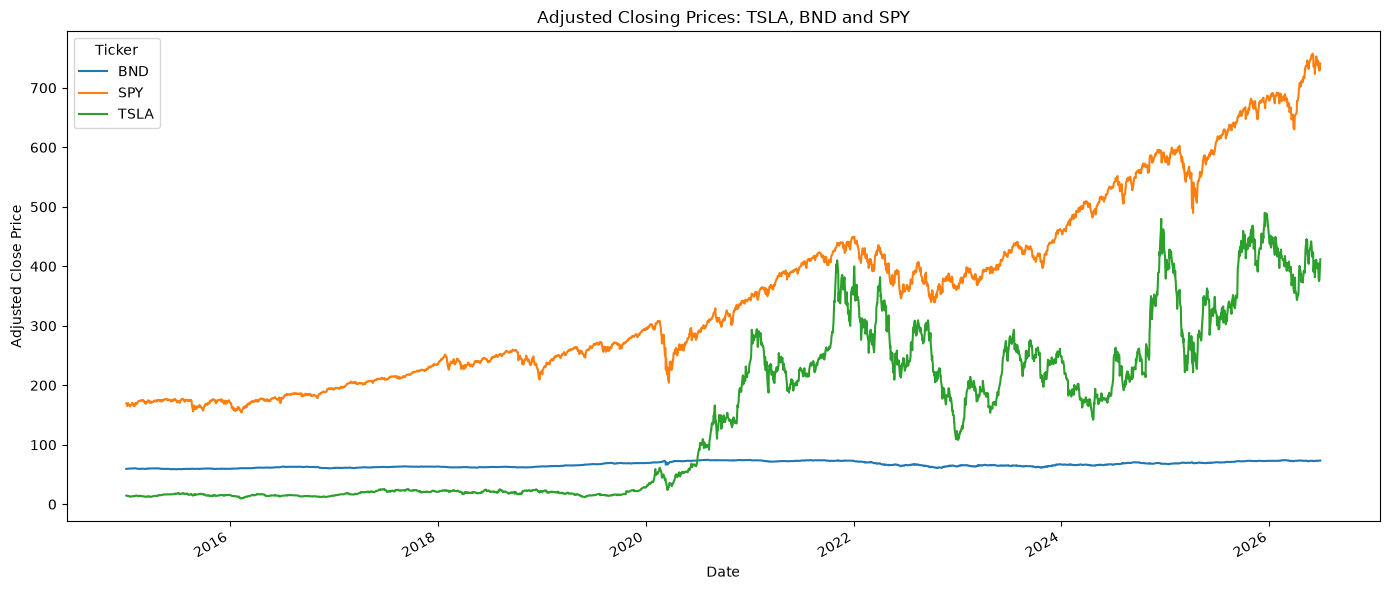

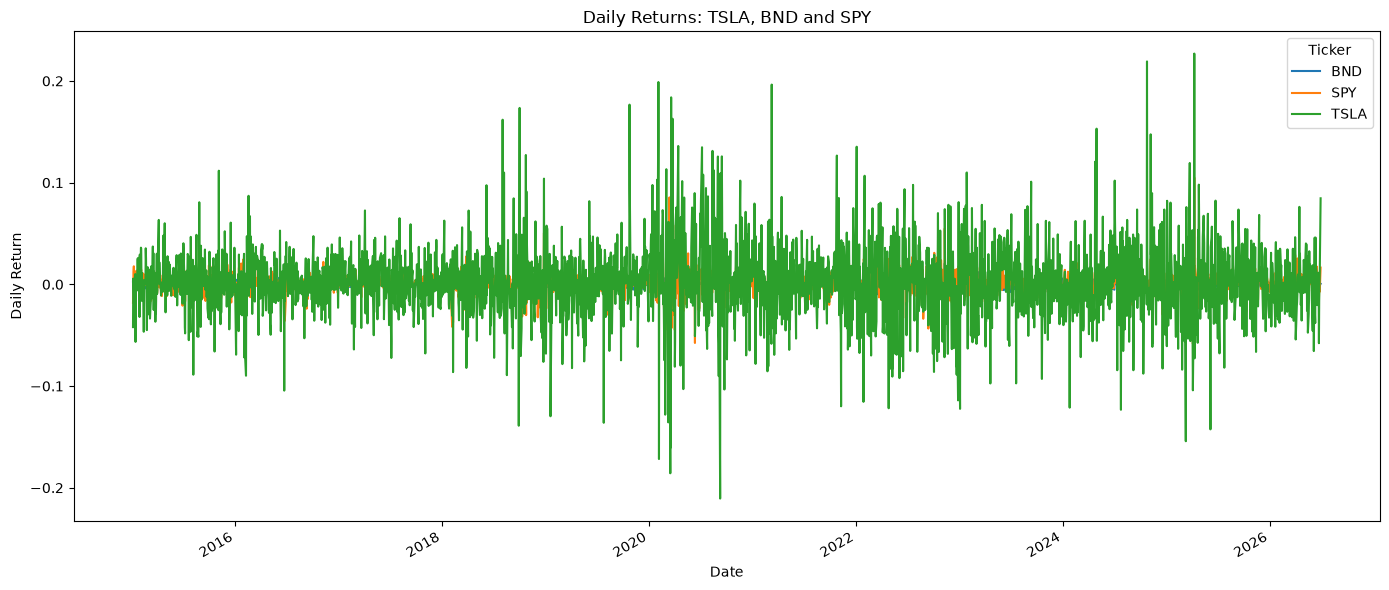

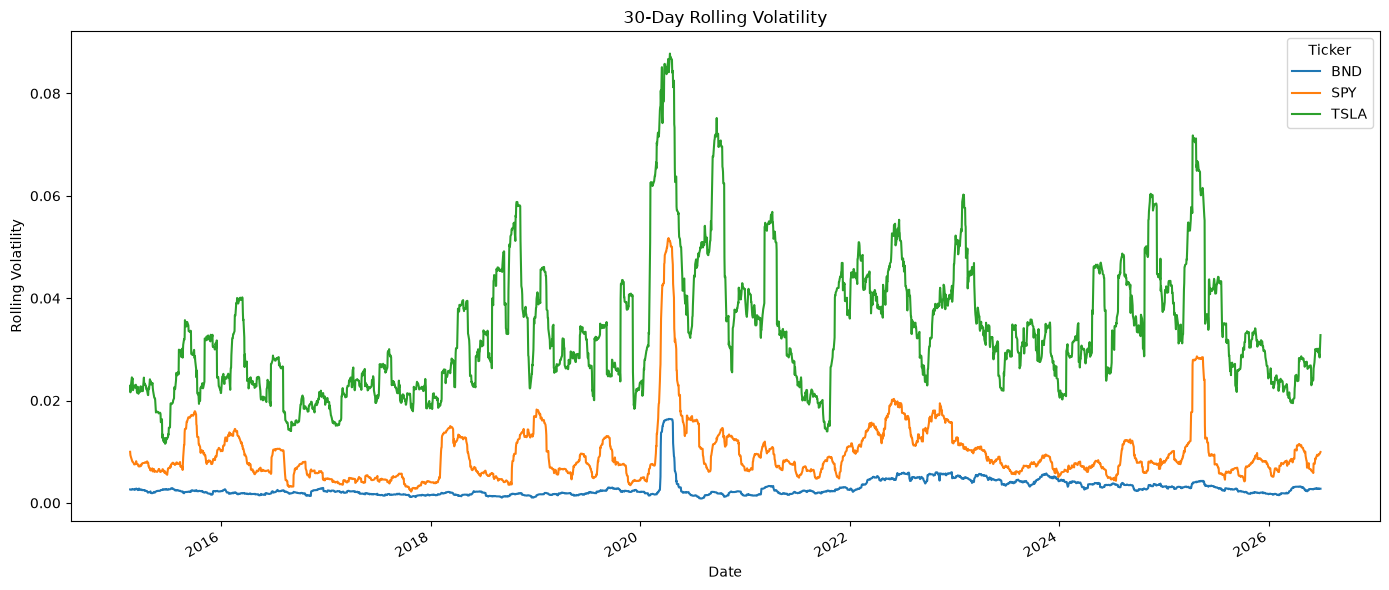

In [8]:
prices.plot(figsize=(14,6), title="Adjusted Closing Prices: TSLA, BND and SPY")
plt.ylabel("Adjusted Close Price")
plt.tight_layout()
plt.savefig("../figures/closing_prices.png")
plt.show()

returns.plot(figsize=(14,6), title="Daily Returns: TSLA, BND and SPY")
plt.ylabel("Daily Return")
plt.tight_layout()
plt.savefig("../figures/daily_returns.png")
plt.show()

rolling_volatility = returns.rolling(30).std()
rolling_volatility.plot(figsize=(14,6), title="30-Day Rolling Volatility")
plt.ylabel("Rolling Volatility")
plt.tight_layout()
plt.savefig("../figures/rolling_volatility.png")
plt.show()

c:\Users\nfepo\Downloads\10 Academy\W9\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\nfepo\Downloads\10 Academy\W9\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\nfepo\Downloads\10 Academy\W9\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\nfepo\Downloads\10 Academy\W9\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_m

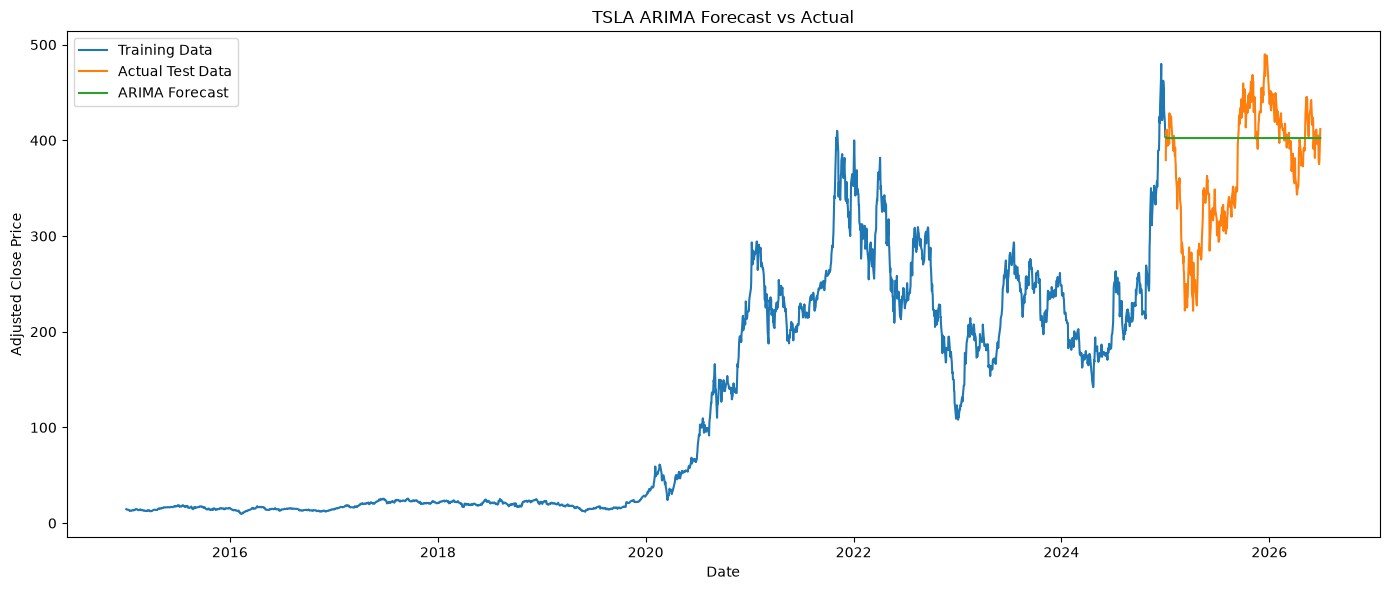

,Model,MAE,RMSE,MAPE
0,"ARIMA(5, 1, 0)",54.144857,69.901398,17.104549


In [9]:
tsla = prices["TSLA"]

model, test_forecast, arima_metrics = train_arima_model(tsla)
arima_metrics.to_csv("../data/processed/arima_results.csv", index=False)

train = tsla.loc[: "2024-12-31"]
test = tsla.loc["2025-01-01":]

plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test_forecast.index, test_forecast, label="ARIMA Forecast")
plt.title("TSLA ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/arima_forecast_vs_actual.png")
plt.show()

display(arima_metrics)

c:\Users\nfepo\Downloads\10 Academy\W9\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\nfepo\Downloads\10 Academy\W9\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


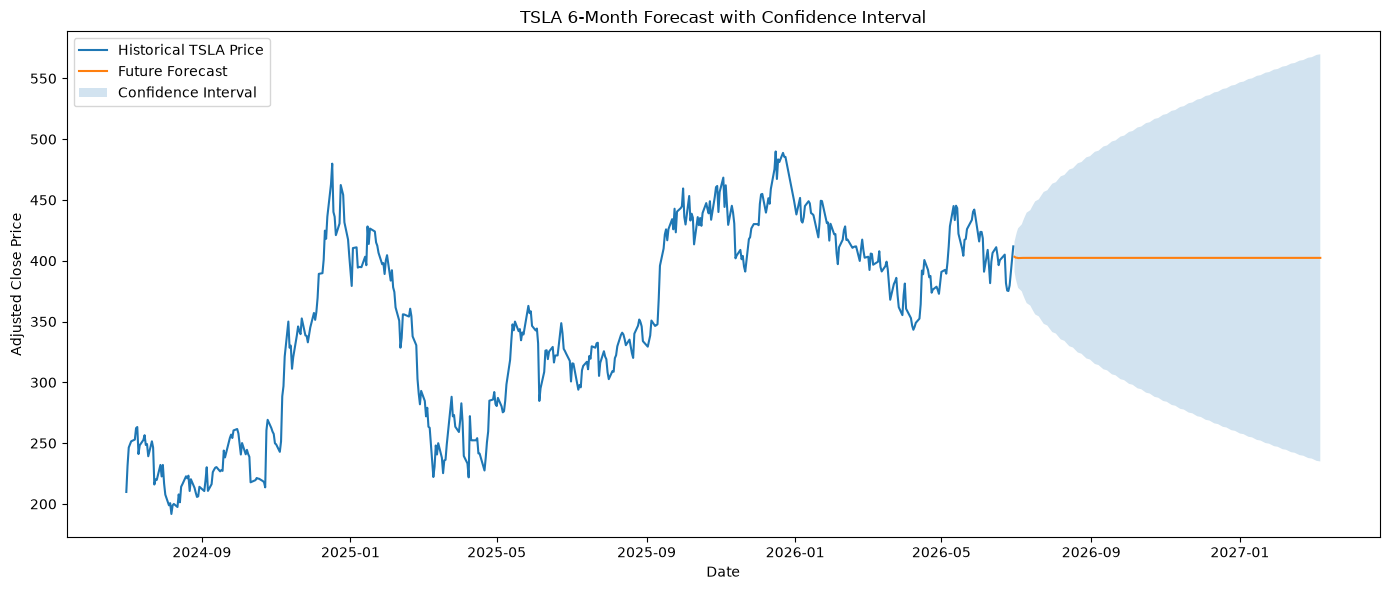

In [10]:
future_forecast, conf_int = forecast_future_prices(model, steps=180)

future_index = pd.date_range(start=tsla.index[-1], periods=181, freq="B")[1:]
future_forecast.index = future_index
conf_int.index = future_index

future_forecast.to_csv("../data/processed/tsla_future_forecast.csv")
conf_int.to_csv("../data/processed/tsla_forecast_confidence_intervals.csv")

plt.figure(figsize=(14,6))
plt.plot(tsla.index[-500:], tsla.iloc[-500:], label="Historical TSLA Price")
plt.plot(future_forecast.index, future_forecast, label="Future Forecast")
plt.fill_between(
    future_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2,
    label="Confidence Interval"
)
plt.title("TSLA 6-Month Forecast with Confidence Interval")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/tsla_future_forecast.png")
plt.show()

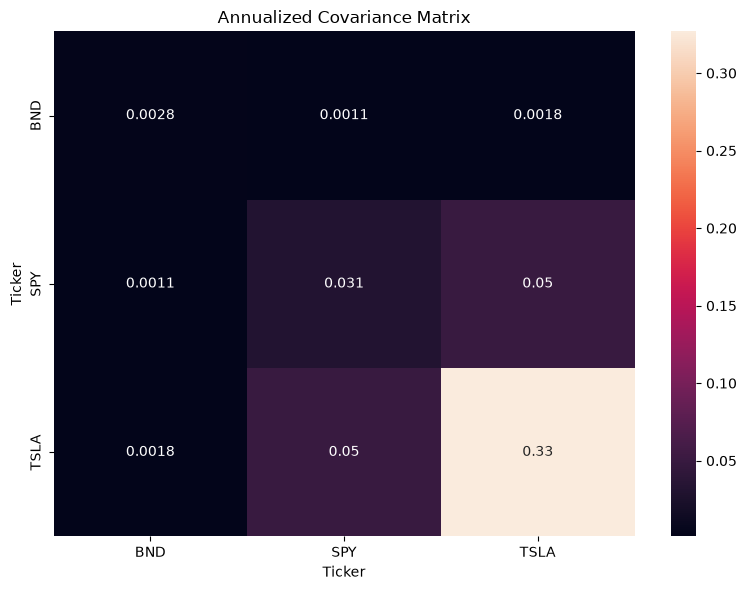

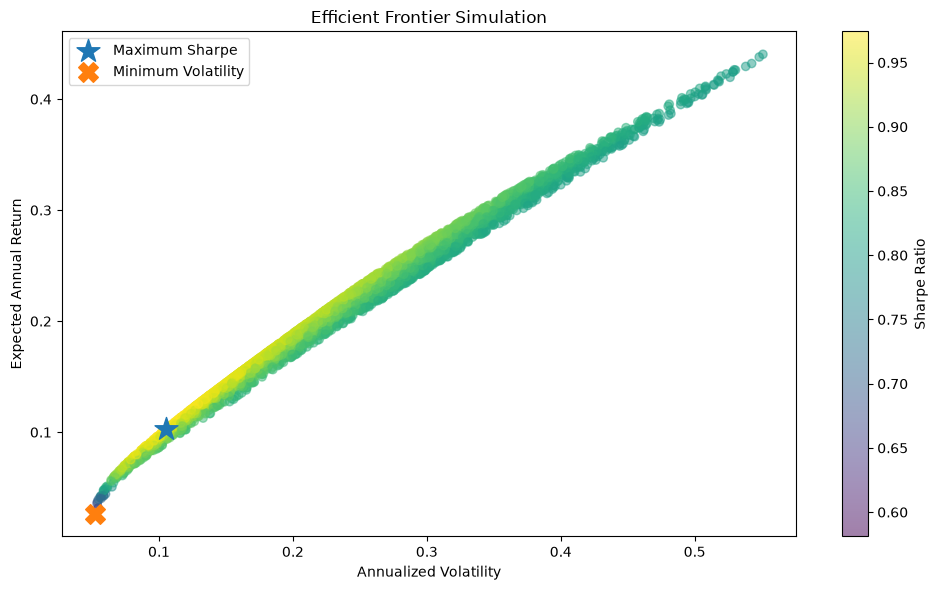

,Asset,Max Sharpe Weight,Minimum Volatility Weight
0,BND,0.577914,0.945598
1,SPY,0.324387,0.054402
2,TSLA,0.097698,0.000000


,Portfolio,Expected Annual Return,Expected Annual Volatility,Sharpe Ratio
0,Maximum Sharpe,0.102727,0.105412,0.974535
1,Minimum Volatility,0.026723,0.052235,0.511589


In [11]:
expected_returns = returns.mean() * 252
covariance_matrix = returns.cov() * 252

max_sharpe_weights = optimize_portfolio(expected_returns, covariance_matrix)
min_vol_weights = minimum_volatility_portfolio(covariance_matrix)

assets = expected_returns.index

portfolio_weights = pd.DataFrame({
    "Asset": assets,
    "Max Sharpe Weight": max_sharpe_weights,
    "Minimum Volatility Weight": min_vol_weights
})

max_return, max_vol, max_sharpe = portfolio_performance(
    max_sharpe_weights, expected_returns, covariance_matrix
)

min_return, min_vol, min_sharpe = portfolio_performance(
    min_vol_weights, expected_returns, covariance_matrix
)

portfolio_summary = pd.DataFrame({
    "Portfolio": ["Maximum Sharpe", "Minimum Volatility"],
    "Expected Annual Return": [max_return, min_return],
    "Expected Annual Volatility": [max_vol, min_vol],
    "Sharpe Ratio": [max_sharpe, min_sharpe]
})

portfolio_weights.to_csv("../data/processed/portfolio_weights.csv", index=False)
portfolio_summary.to_csv("../data/processed/portfolio_summary.csv", index=False)
covariance_matrix.to_csv("../data/processed/covariance_matrix.csv")

plt.figure(figsize=(8,6))
sns.heatmap(covariance_matrix, annot=True)
plt.title("Annualized Covariance Matrix")
plt.tight_layout()
plt.savefig("../figures/covariance_heatmap.png")
plt.show()

random_portfolios = simulate_random_portfolios(expected_returns, covariance_matrix)

plt.figure(figsize=(10,6))
plt.scatter(
    random_portfolios["Volatility"],
    random_portfolios["Return"],
    c=random_portfolios["Sharpe Ratio"],
    alpha=0.5
)
plt.colorbar(label="Sharpe Ratio")
plt.scatter(max_vol, max_return, marker="*", s=300, label="Maximum Sharpe")
plt.scatter(min_vol, min_return, marker="X", s=200, label="Minimum Volatility")
plt.title("Efficient Frontier Simulation")
plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/efficient_frontier.png")
plt.show()

display(portfolio_weights)
display(portfolio_summary)

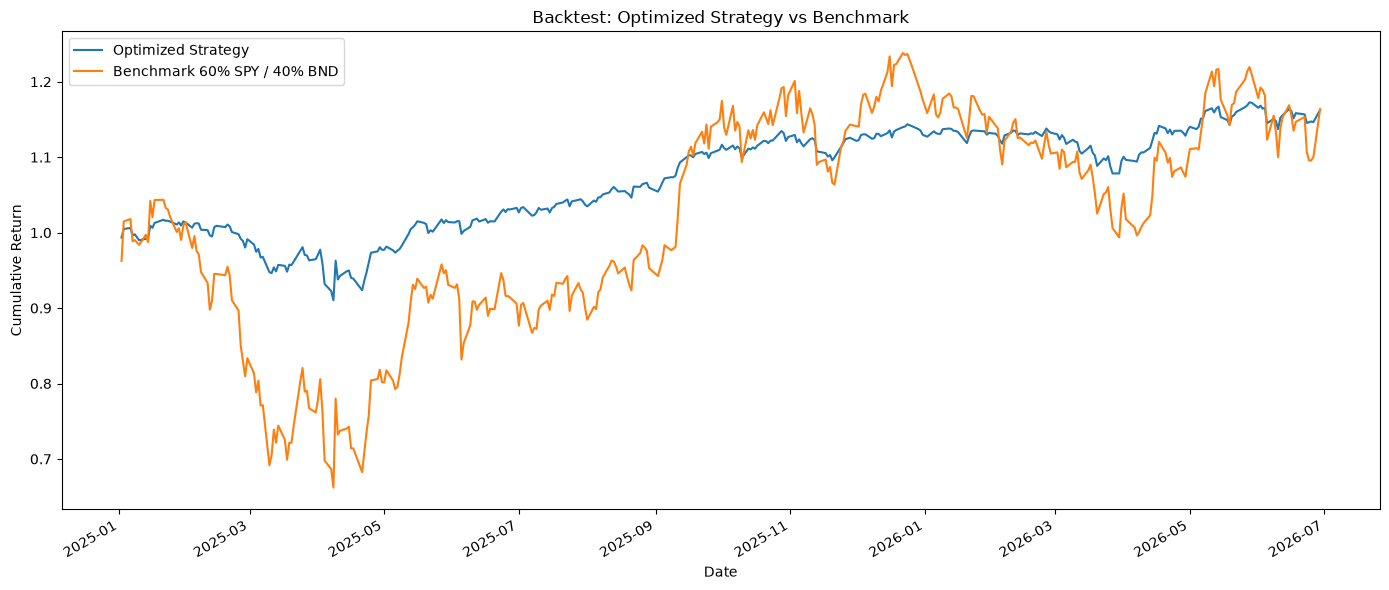

,Portfolio,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,Optimized Strategy,0.162561,0.108173,0.111011,0.974438,-0.104871
1,Benchmark 60% SPY / 40% BND,0.163646,0.180224,0.396074,0.455025,-0.365508


In [12]:
backtest_returns = returns.loc["2025-01-01":]

strategy_weights = portfolio_weights["Max Sharpe Weight"].values
benchmark_weights = [0.0, 0.4, 0.6]  # TSLA, BND, SPY

cumulative, backtest_metrics = backtest_strategy(
    backtest_returns,
    strategy_weights,
    benchmark_weights
)

cumulative.to_csv("../data/processed/backtest_cumulative_returns.csv")
backtest_metrics.to_csv("../data/processed/backtest_metrics.csv", index=False)

cumulative.plot(figsize=(14,6), title="Backtest: Optimized Strategy vs Benchmark")
plt.ylabel("Cumulative Return")
plt.tight_layout()
plt.savefig("../figures/backtest_strategy_vs_benchmark.png")
plt.show()

display(backtest_metrics)